#### Load, Clean and Prepare Data

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from itertools import product
from openpyxl import Workbook

# load dataset
df = pd.read_csv("../data/coffee_shop_sales.csv")

# display information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (149116, 11)

Columns:
['Transaction ID', 'Transaction Date', 'Transaction Time', 'Transaction Quantity', 'Store ID', 'Store Location', 'Product ID', 'Unit Price', 'Product Category', 'Product Type', 'Product Detail']


In [185]:
# count missing values
missing_values = df.isnull().sum()

print("missing values:", missing_values)

# chow only columns that contain missing values
print("\ncolumns with missing values:")
print(missing_values[missing_values > 0])

missing values: Transaction ID          0
Transaction Date        0
Transaction Time        0
Transaction Quantity    0
Store ID                0
Store Location          0
Product ID              0
Unit Price              0
Product Category        0
Product Type            0
Product Detail          0
dtype: int64

columns with missing values:
Series([], dtype: int64)


In [186]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,missing_count,missing_percent
Transaction ID,0,0.0
Transaction Date,0,0.0
Transaction Time,0,0.0
Transaction Quantity,0,0.0
Store ID,0,0.0
Store Location,0,0.0
Product ID,0,0.0
Unit Price,0,0.0
Product Category,0,0.0
Product Type,0,0.0


In [187]:
print(df.dtypes)

Transaction ID            int64
Transaction Date            str
Transaction Time            str
Transaction Quantity      int64
Store ID                  int64
Store Location              str
Product ID                int64
Unit Price              float64
Product Category            str
Product Type                str
Product Detail              str
dtype: object


In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Transaction ID        149116 non-null  int64  
 1   Transaction Date      149116 non-null  str    
 2   Transaction Time      149116 non-null  str    
 3   Transaction Quantity  149116 non-null  int64  
 4   Store ID              149116 non-null  int64  
 5   Store Location        149116 non-null  str    
 6   Product ID            149116 non-null  int64  
 7   Unit Price            149116 non-null  float64
 8   Product Category      149116 non-null  str    
 9   Product Type          149116 non-null  str    
 10  Product Detail        149116 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 12.5 MB


In [189]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

print("\nTransaction Date:", df["Transaction Date"].dtype)


Transaction Date: datetime64[us]


/var/folders/53/vr8gs__x60sg207tybh25bv80000gn/T/ipykernel_75178/3106514235.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Transaction Date"] = pd.to_datetime(


In [190]:
# check is any dates failed conversion
invalid_dates = df["Transaction Date"].isna().sum()

print("invalid dates:", invalid_dates)

invalid dates: 0


In [191]:
duplicate_count = df.duplicated().sum()

print("duplicates:", duplicate_count)

duplicates: 398


In [192]:
# inspect duplicates
duplicates = df[df.duplicated(keep=False)]

# duplicates.head(20)

##### note on duplicate rows
Duplicate-looking transactions were retained because each record has a unique Transaction ID. Identical transaction details do not necessarily indicate duplicate records and may represent separate sales occurring at the same time. Quantities are aggregated during analysis rather than altering the original transaction-level data.

In [193]:
categorical_columns = [
    "Store Location",
    "Product Category",
    "Product Type",
    "Product Detail"
]

for column in categorical_columns:
    print(f"\n{column}:", df[column].nunique(), "unique values:")
    print(df[column].unique())


Store Location: 3 unique values:
<StringArray>
['Lower Manhattan', 'Hell's Kitchen', 'Astoria']
Length: 3, dtype: str

Product Category: 9 unique values:
<StringArray>
[            'Coffee',                'Tea', 'Drinking Chocolate',
             'Bakery',           'Flavours',          'Loose Tea',
       'Coffee beans', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

Product Type: 29 unique values:
<StringArray>
['Gourmet brewed coffee',       'Brewed Chai tea',         'Hot chocolate',
           'Drip coffee',                 'Scone',      'Barista Espresso',
      'Brewed Black tea',      'Brewed Green tea',     'Brewed herbal tea',
              'Biscotti',                'Pastry', 'Organic brewed coffee',
 'Premium brewed coffee',         'Regular syrup',            'Herbal tea',
         'Gourmet Beans',         'Organic Beans',      'Sugar free syrup',
    'Drinking Chocolate',         'Premium Beans',              'Chai tea',
           'Green beans',    

In [194]:
for column in categorical_columns:
    spaces = df[column].astype(str).str.strip().ne(df[column].astype(str)).sum()
    
    print(f"{column}: {spaces} values with leading/trailing spaces")

Store Location: 0 values with leading/trailing spaces
Product Category: 0 values with leading/trailing spaces
Product Type: 0 values with leading/trailing spaces
Product Detail: 1952 values with leading/trailing spaces


In [195]:
numeric_columns = [
    "Transaction ID",
    "Transaction Quantity",
    "Store ID",
    "Product ID",
    "Unit Price"
]

for column in numeric_columns:
    converted = pd.to_numeric(df[column], errors="coerce")
    invalid = converted.isna().sum()

    print(f"{column}: {invalid} non-numeric values")

Transaction ID: 0 non-numeric values
Transaction Quantity: 0 non-numeric values
Store ID: 0 non-numeric values
Product ID: 0 non-numeric values
Unit Price: 0 non-numeric values


In [196]:
print("Transaction Quantity:")
print(df["Transaction Quantity"].describe())

print("\nUnit Price:")
print(df["Unit Price"].describe())

Transaction Quantity:
count    149116.000000
mean          1.438276
std           0.542509
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           8.000000
Name: Transaction Quantity, dtype: float64

Unit Price:
count    149116.000000
mean          3.382219
std           2.658723
min           0.800000
25%           2.500000
50%           3.000000
75%           3.750000
max          45.000000
Name: Unit Price, dtype: float64


In [197]:
data_quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique(),
    "duplicate_values": df.duplicated().sum()
})

data_quality_summary

,data_type,missing_count,missing_percent,unique_values,duplicate_values
Transaction ID,int64,0,0.0,116129,398
Transaction Date,datetime64[us],0,0.0,181,398
Transaction Time,str,0,0.0,25762,398
Transaction Quantity,int64,0,0.0,6,398
Store ID,int64,0,0.0,3,398
Store Location,str,0,0.0,3,398
Product ID,int64,0,0.0,80,398
Unit Price,float64,0,0.0,41,398
Product Category,str,0,0.0,9,398
Product Type,str,0,0.0,29,398


#### Calculate Business Metrics

In [198]:
df["Revenue"] = df["Transaction Quantity"] * df["Unit Price"]

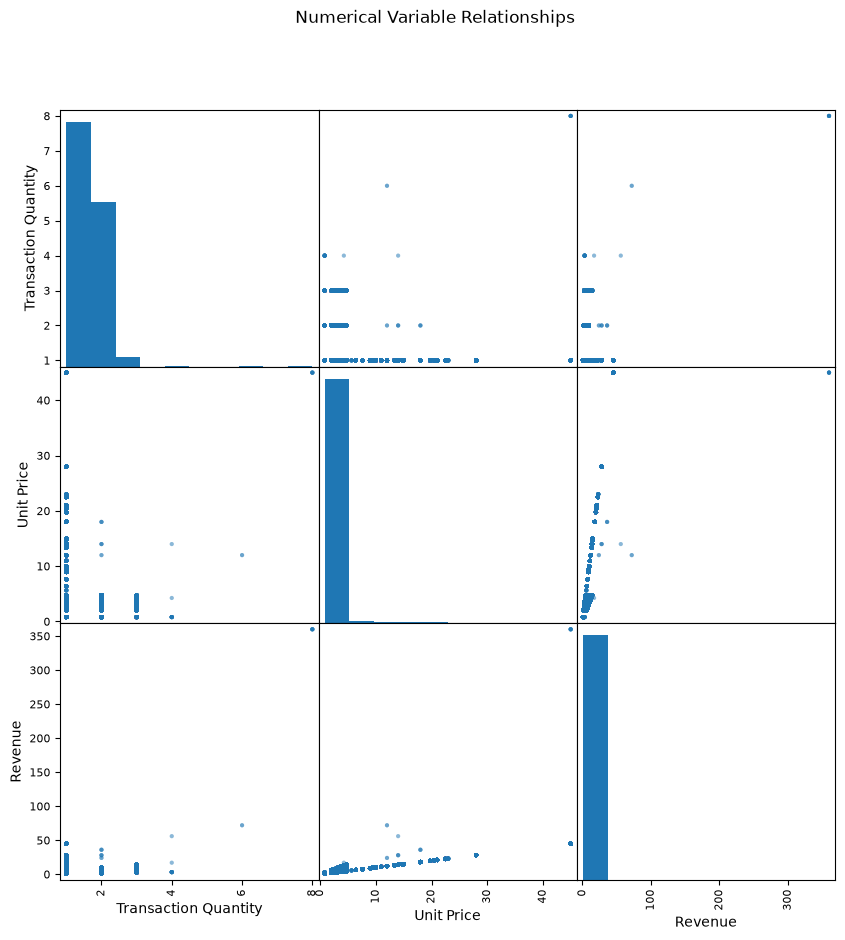

In [199]:
numeric_columns = [
    "Transaction Quantity",
    "Unit Price",
    "Revenue"
]

pd.plotting.scatter_matrix(
    df[numeric_columns],
    figsize=(10, 10),
    alpha=0.3
)

plt.suptitle("Numerical Variable Relationships")
plt.show()

##### Note on scatter plots
Scatter plots were used to examine relationships between the numerical variables. No meaningful patterns or strong relationships were identified. The scatter plots did not provide significant business insights.

In [200]:
# total revenue

total_revenue = df["Revenue"].sum()

print(f"total revenue: ${total_revenue:,.2f}")

total revenue: $698,812.33


In [201]:
# transcations (counting unique transaction IDs)

number_of_transactions = df["Transaction ID"].nunique()

print(f"total transactions: {number_of_transactions:,}")

total transactions: 116,129


In [202]:
# average revenue per transaction
average_transaction_value = (
    df.groupby("Transaction ID")["Revenue"]
      .sum()
      .mean()
)

print(f"average transaction: ${average_transaction_value:,.2f}")


average transaction: $6.02


In [203]:
# sales by product category

category_sales = (
    df.groupby("Product Category")
      .agg(
          revenue=("Revenue", "sum"),
          units_sold=("Transaction Quantity", "sum"),
          transactions=("Transaction ID", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

category_sales

,revenue,units_sold,transactions
Product Category,,,
Coffee,269952.45,89250,58007
Tea,196405.95,69737,45209
Bakery,82315.64,23214,22332
Drinking Chocolate,72416.00,17457,11452
Coffee beans,40085.25,1828,1750
Branded,13607.00,776,747
Loose Tea,11213.60,1210,1210
Flavours,8408.80,10511,6766
Packaged Chocolate,4407.64,487,487


In [204]:
# sales by product

product_sales = (
    df.groupby("Product Detail")
      .agg(
          revenue=("Revenue", "sum"),
          units_sold=("Transaction Quantity", "sum"),
          transactions=("Transaction ID", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

product_sales

,revenue,units_sold,transactions
Product Detail,,,
Sustainably Grown Organic Lg,21151.75,4453,2961
Dark chocolate Lg,21006.00,4668,3025
Latte Rg,19112.25,4497,2886
Cappuccino Lg,17641.75,4151,2764
Morning Sunrise Chai Lg,17384.00,4346,2827
...,...,...,...
Lemon Grass,1360.40,152,152
Guatemalan Sustainably Grown,1340.00,134,134
Spicy Eye Opener Chai,1335.90,122,122


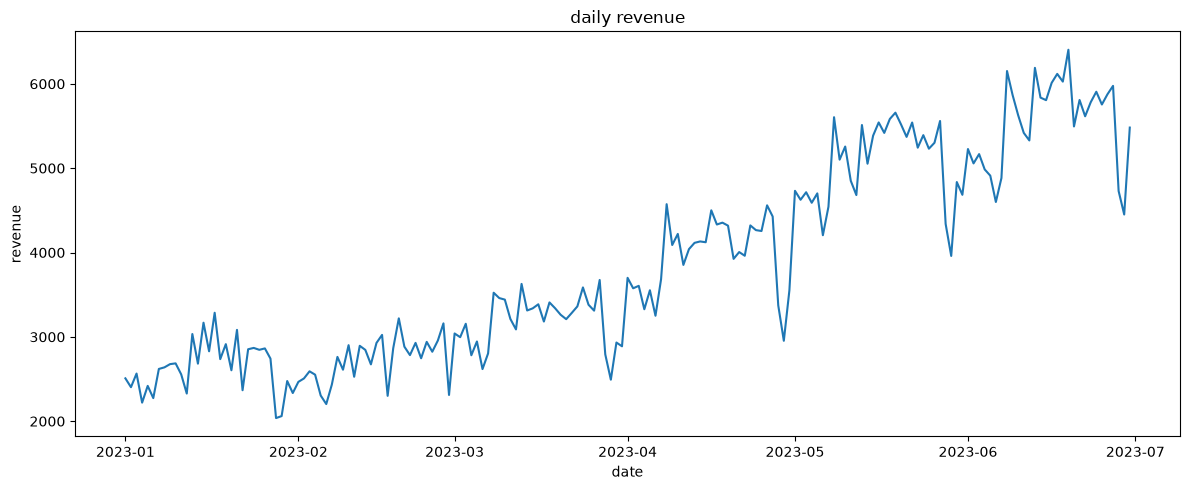

In [205]:
# sales by day

df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

sales_by_day = (
    df.groupby("Transaction Date")["Revenue"]
      .sum()
      .sort_index()
)

# print(sales_by_day)

# plot start
plt.figure(figsize=(12, 5))

plt.plot(
    sales_by_day.index,
    sales_by_day.values
)

plt.xlabel("date")
plt.ylabel("revenue")
plt.title("daily revenue")

plt.tight_layout()

plt.show()


In [206]:
# sales by day of week

df["Day of Week"] = df["Transaction Date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sales_by_weekday = (
    df.groupby("Day of Week")["Revenue"]
      .sum()
      .reindex(day_order)
)

sales_by_weekday

Day of Week
Monday       101677.28
Tuesday       99455.94
Wednesday    100313.54
Thursday     100767.78
Friday       101373.00
Saturday      96894.48
Sunday        98330.31
Name: Revenue, dtype: float64

peak hour: 10:00
revenue: $88,673.39


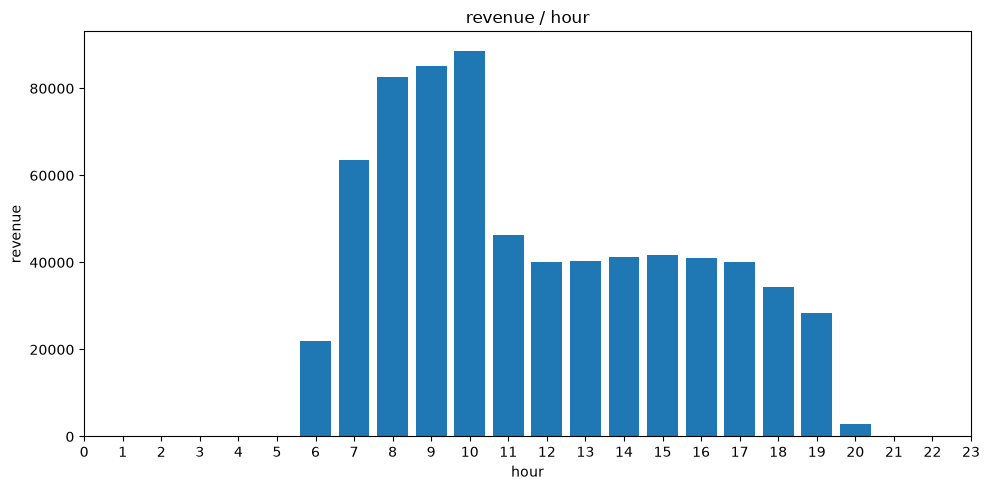

In [207]:
daily_sales = (
    df.groupby("Transaction Date")
      .agg(
          revenue=("Revenue", "sum"),
          timeransactions=("Transaction ID", "nunique"),
          units_sold=("Transaction Quantity", "sum")
      )
      .sort_values("revenue", ascending=False)
)

daily_sales.head(10)

# peak hours
# convert it to time

df["Transaction Time"] = pd.to_datetime(
    df["Transaction Time"],
    format="%H:%M:%S",
    errors="coerce"
)

# extract hour

df["Transaction Hour"] = df["Transaction Time"].dt.hour

# sales by hour

sales_by_hour = (
    df.groupby("Transaction Hour")
      .agg(
          revenue=("Revenue", "sum"),
          transactions=("Transaction ID", "nunique"),
          units_sold=("Transaction Quantity", "sum")
      )
      .sort_index()
)

sales_by_hour

# find peak(s)

peak_hour = sales_by_hour["revenue"].idxmax()
peak_hour_revenue = sales_by_hour["revenue"].max()

print(f"peak hour: {peak_hour}:00")
print(f"revenue: ${peak_hour_revenue:,.2f}")

# plot start
plt.figure(figsize=(10, 5))

plt.bar(
    sales_by_hour.index,
    sales_by_hour["revenue"]
)

plt.xlabel("hour")
plt.ylabel("revenue")
plt.title("revenue / hour")

plt.xticks(range(0, 24))
plt.tight_layout()

plt.show()

Transaction Hour       6        7         8         9         10       11  \
Day of Week                                                                 
Monday            3098.58  9516.52  11604.69  11898.33  12427.25  7179.09   
Tuesday           2320.25  8841.71  12950.19  13588.47  13497.68  5877.41   
Wednesday         3396.23  8905.86  11991.45  12246.40  12382.48  7055.85   
Thursday          3464.90  9209.23  11420.49  10963.73  12091.09  6898.55   
Friday            3385.73  9386.04  11746.65  12750.00  13155.66  6827.84   
Saturday          2913.85  8775.02  11370.86  11333.85  12736.48  6361.41   
Sunday            3320.73  8892.09  11615.54  12388.75  12382.75  6118.99   

Transaction Hour       12       13       14       15       16       17  \
Day of Week                                                              
Monday            6139.64  5771.26  6463.31  6159.49  6139.96  5927.35   
Tuesday           5172.64  5443.46  5621.56  5852.24  5723.78  5609.85   
Wednesday 

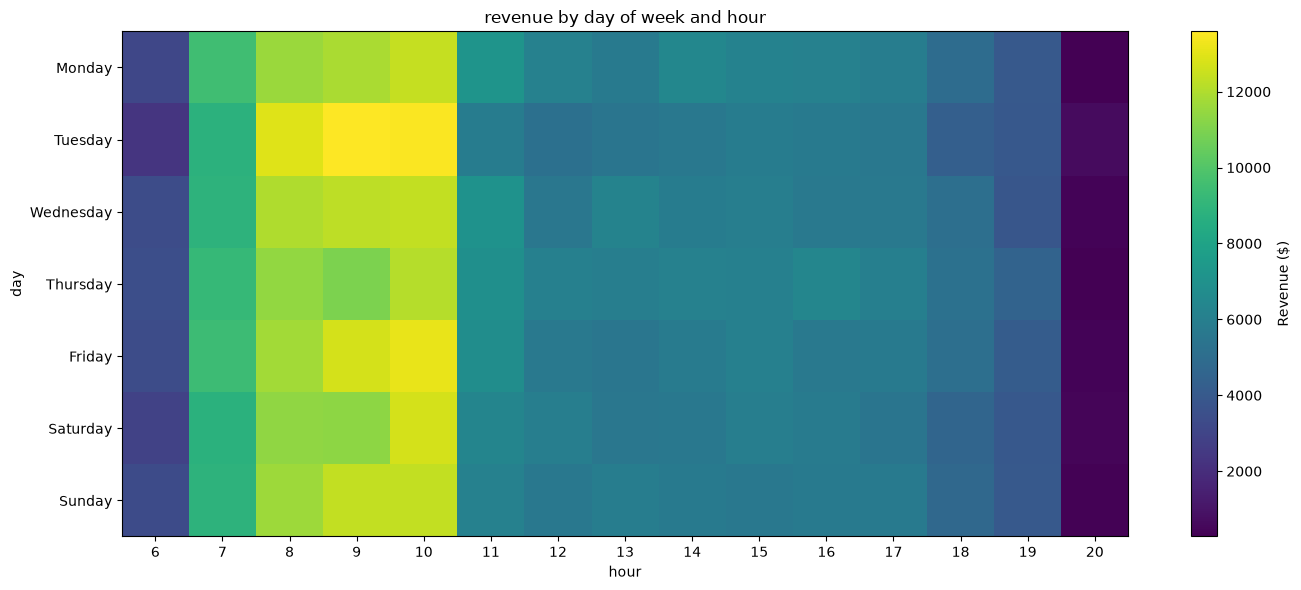

In [208]:
revenue_by_day_hour = (
    df.groupby(["Day of Week", "Transaction Hour"])["Revenue"]
      .sum()
      .unstack(fill_value=0)
      .reindex(day_order)
)

print(revenue_by_day_hour)

# plot start

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.imshow(
    revenue_by_day_hour,
    aspect="auto"
)

plt.colorbar(label="Revenue ($)")

plt.xticks(
    range(len(revenue_by_day_hour.columns)),
    revenue_by_day_hour.columns
)

plt.yticks(
    range(len(revenue_by_day_hour.index)),
    revenue_by_day_hour.index
)

plt.xlabel("hour")
plt.ylabel("day")
plt.title("revenue by day of week and hour")

plt.tight_layout()
plt.show()

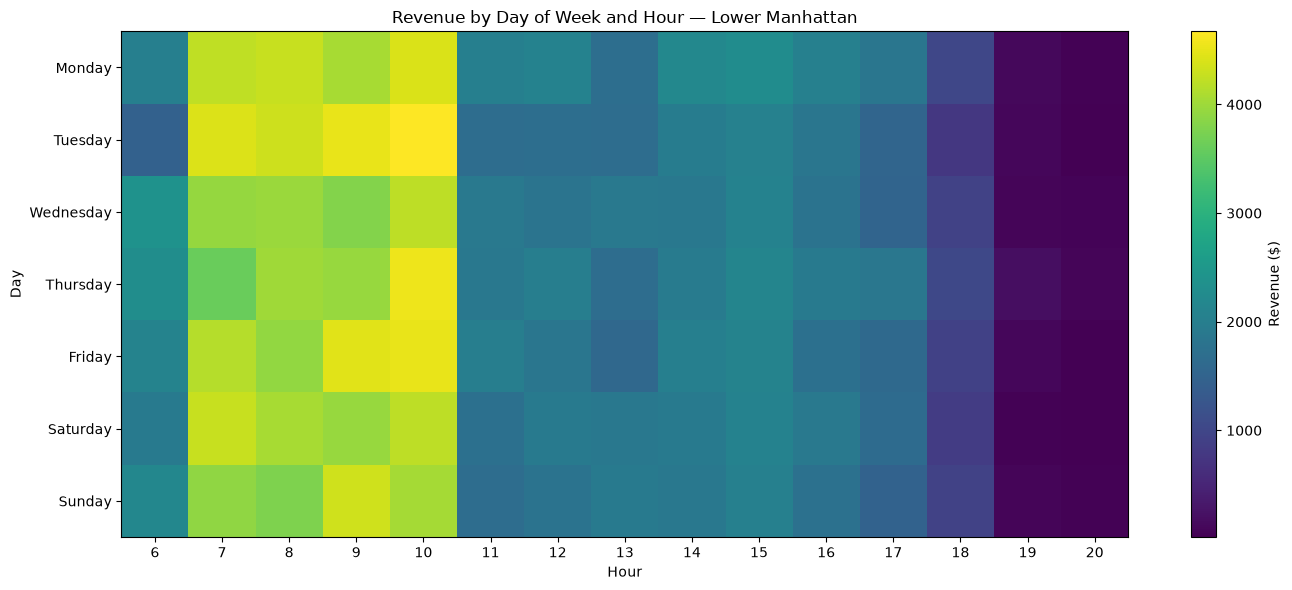

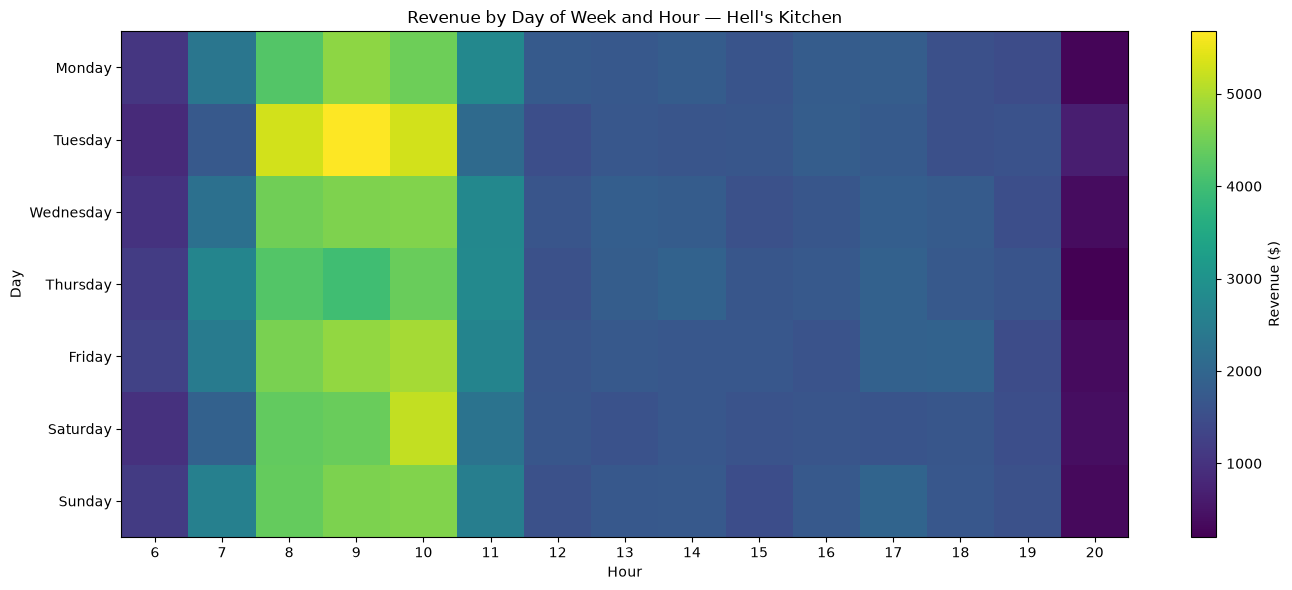

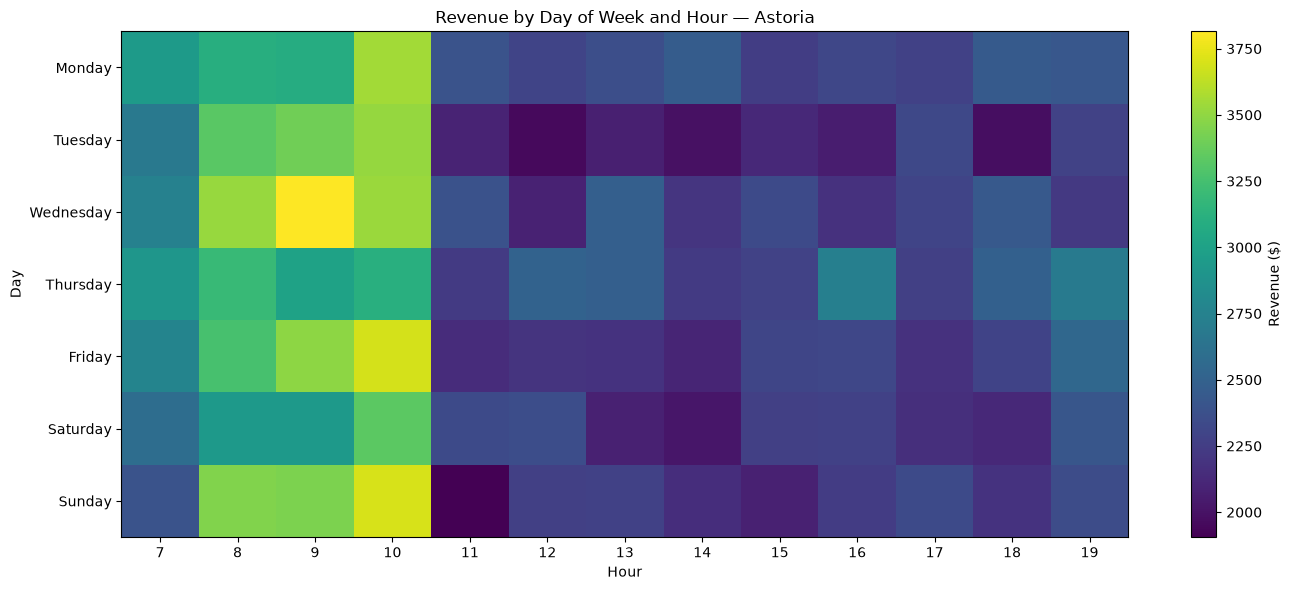

In [226]:
for location in df["Store Location"].unique():

    revenue_by_day_hour = (
        df[df["Store Location"] == location]
        .groupby(["Day of Week", "Transaction Hour"])["Revenue"]
        .sum()
        .unstack(fill_value=0)
        .reindex(day_order)
    )

    # print(location)
    # print(revenue_by_day_hour)

    # plot
    plt.figure(figsize=(14, 6))

    plt.imshow(
        revenue_by_day_hour,
        aspect="auto"
    )

    plt.colorbar(label="Revenue ($)")

    plt.xticks(
        range(len(revenue_by_day_hour.columns)),
        revenue_by_day_hour.columns
    )

    plt.yticks(
        range(len(revenue_by_day_hour.index)),
        revenue_by_day_hour.index
    )

    plt.xlabel("Hour")
    plt.ylabel("Day")
    plt.title(f"Revenue by Day of Week and Hour — {location}")

    plt.tight_layout()
    plt.show()

#### sales by month

Month
2023-01     81677.74
2023-02     76145.19
2023-03     98834.68
2023-04    118941.08
2023-05    156727.76
2023-06    166485.88
Freq: M, Name: Revenue, dtype: float64


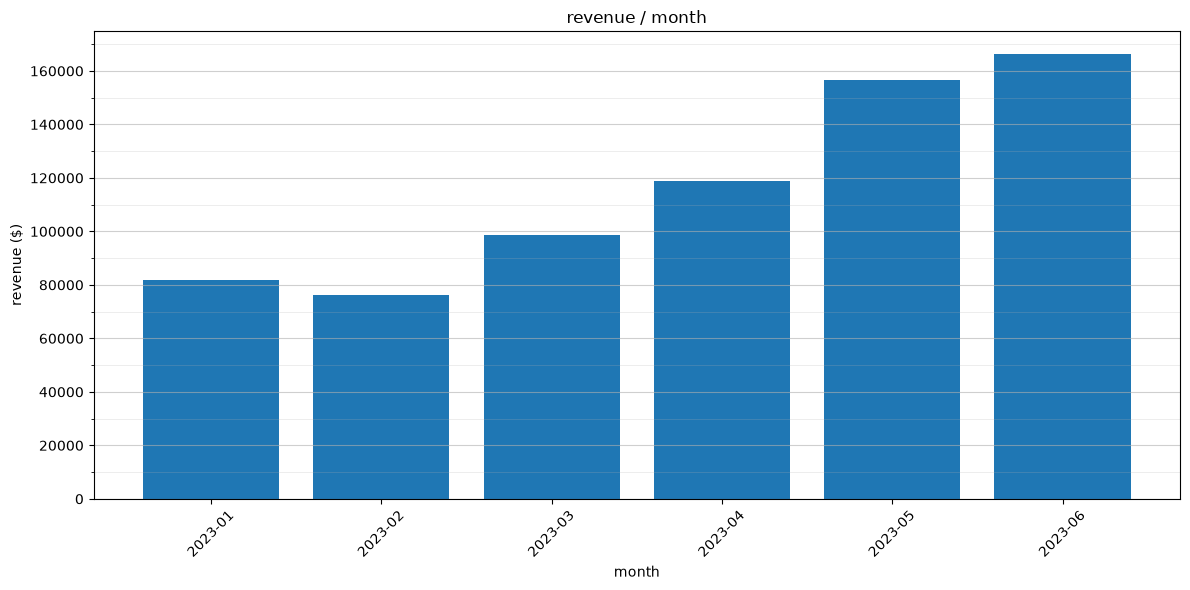

In [209]:
df["Month"] = df["Transaction Date"].dt.to_period("M")

sales_by_month = (
    df.groupby("Month")["Revenue"]
      .sum()
)

print(sales_by_month)

# plot start

plt.figure(figsize=(12, 6))

plt.bar(
    sales_by_month.index.astype(str),
    sales_by_month.values
)

plt.xlabel("month")
plt.ylabel("revenue ($)")
plt.title("revenue / month")

plt.xticks(rotation=45)

# major gridlines

plt.grid(
    axis="y",
    which="major",
    linewidth=0.8,
    alpha=0.6
)

# minor gridlines
ax = plt.gca()
ax.yaxis.set_minor_locator(MultipleLocator(10000))
ax.yaxis.set_major_locator(MultipleLocator(20000))


plt.grid(
    axis="y",
    which="minor",
    linewidth=0.4,
    alpha=0.4
)

plt.tight_layout()
plt.show()

#### sales by store / location

In [210]:
store_sales = (
    df.groupby(["Store ID", "Store Location"])
      .agg(
          revenue=("Revenue", "sum"),
          units_sold=("Transaction Quantity", "sum"),
          transactions=("Transaction ID", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

store_sales

,,revenue,units_sold,transactions
Store ID,Store Location,,,
8,Hell's Kitchen,236511.17,71737,40454
3,Astoria,232243.91,70991,40684
5,Lower Manhattan,230057.25,71742,35652


#### what sells when

In [211]:
df["Transaction Hour"].value_counts().sort_index()

Transaction Hour
6      4594
7     13428
8     17654
9     17764
10    18545
11     9766
12     8708
13     8714
14     8933
15     8979
16     9093
17     8745
18     7498
19     6092
20      603
Name: count, dtype: int64



sales_by_period_category
Product Category    Bakery  Branded     Coffee  Coffee beans  \
Time Period                                                    
Morning           31568.14   6293.0   92986.55      17274.65   
Lunch              9792.50   1002.0   34351.05       4679.35   
Afternoon          9480.16   1429.0   33462.40       3147.25   
Evening           31474.84   4883.0  109152.45      14984.00   

Product Category  Drinking Chocolate  Flavours  Loose Tea  Packaged Chocolate  \
Time Period                                                                     
Morning                     25231.25    3816.8    5319.50             1928.30   
Lunch                        9270.25     760.8     934.45              350.48   
Afternoon                    9093.75     668.8     894.55              439.28   
Evening                     28820.75    3162.4    4065.10             1689.58   

Product Category       Tea  
Time Period                 
Morning           68877.95  
Lunch         

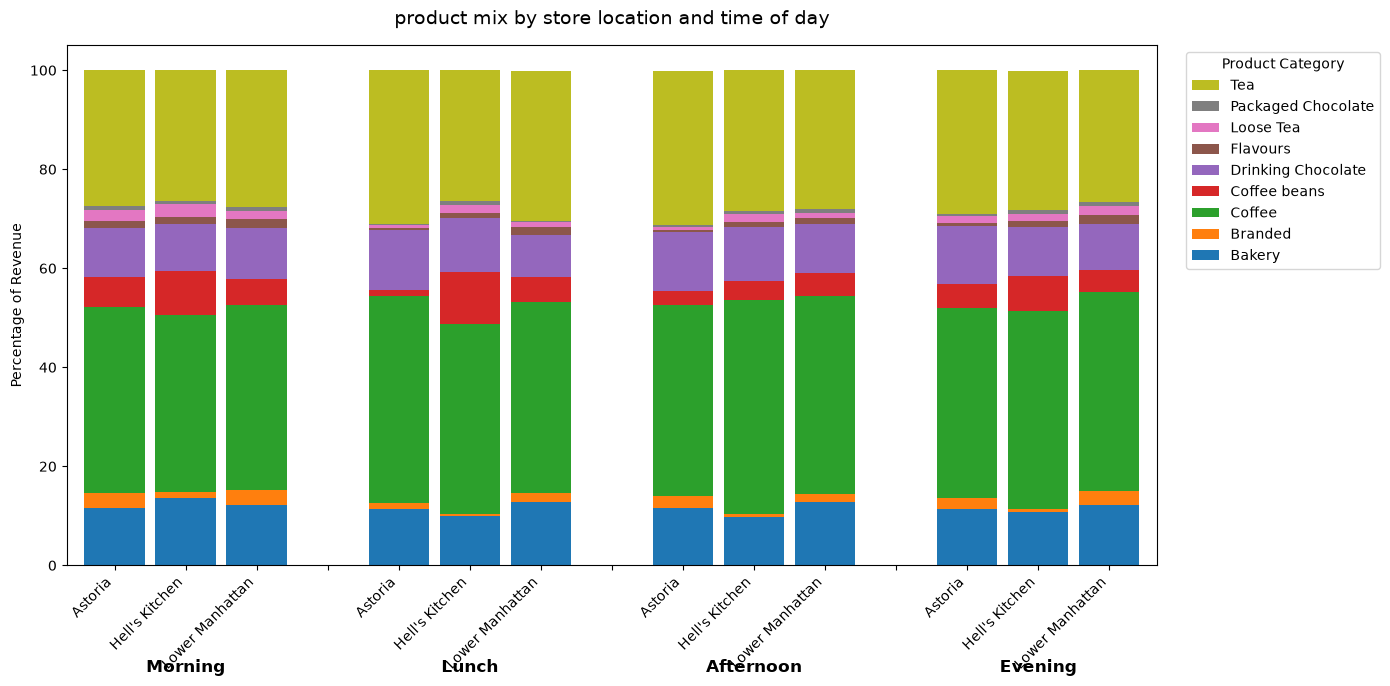

In [212]:
def time_period(hour):
    if 6 <= hour < 10:
        return "Morning"
    elif 11 <= hour < 13:
        return "Lunch"
    elif 14 <= hour < 16:
        return "Afternoon"
    else:
        return "Evening"


df["Time Period"] = df["Transaction Hour"].apply(time_period)

time_order = [ "Morning", "Lunch", "Afternoon", "Evening" ]

df["Time Period"] = pd.Categorical( df["Time Period"], categories=time_order, ordered=True )

# revenue by product category and time period
sales_by_period_category = (
    df.groupby(["Time Period", "Product Category"])["Revenue"]
      .sum()
      .unstack(fill_value=0)
)

print("\n\nsales_by_period_category")
print(sales_by_period_category)

# units sold by product category and time period
units_by_period_category = (
    df.groupby(
        ["Time Period", "Product Category"],
        observed=True
    )["Transaction Quantity"]
    .sum()
    .unstack(fill_value=0)
)

# time periods in chronological order
units_by_period_category = units_by_period_category.reindex(
    ["Morning", "Lunch", "Afternoon", "Evening"]
)

print("\nunits_by_period_category")
print(units_by_period_category)

# percentage of category revenue by time period
category_time_share = (
    df.groupby(
        ["Product Category", "Time Period"],
        observed=True
    )["Revenue"]
    .sum()
    .unstack(fill_value=0)
)

# time periods in chronological order
category_time_share = category_time_share.reindex(
    columns=["Morning", "Lunch", "Afternoon", "Evening"],
    fill_value=0
)

category_time_share = (
    category_time_share
    .div(category_time_share.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

print("\n\ncategory_time_share")
print(category_time_share)


# plot start

# DATA PREP

product_order = [
    "Bakery",
    "Branded",
    "Coffee",
    "Coffee beans",
    "Drinking Chocolate",
    "Flavours",
    "Loose Tea",
    "Packaged Chocolate",
    "Tea",
]
time_order = ["Morning", "Lunch", "Afternoon", "Evening"]

# calculate raw revenue aggregated by location, time, and product category
location_period_product = (
    df.groupby(
        ["Store Location", "Time Period", "Product Category"], observed=True
    )["Revenue"]
    .sum()
    .unstack(fill_value=0)
)

# force every row to contain every product category in same order
location_period_product = location_period_product.reindex(
    columns=product_order, fill_value=0
)

# calculate percentage breakdown of share within each location and time period
location_period_product_share = (
    location_period_product.div(location_period_product.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

# fetch unique locations from data index
locations = (
    location_period_product_share.index.get_level_values("Store Location")
    .unique()
    .tolist()
)

# ALIGN MULTIINDEX LABELS & CREATE GAP SPACES

# swap row levels so "Time Period" is outer
plot_data = location_period_product_share.swaplevel(
    "Store Location", "Time Period"
)

# rebuild dataframe to insert gap rows
spaced_records = []
x_labels = []
time_centers = []
current_bar_index = 0
num_locs = len(locations)

for i, time_period in enumerate(time_order):
    # calculate visual center for the time block header text
    group_start_idx = current_bar_index
    
    for loc in locations:
        # pull matching data if it exists, otherwise provide a zero-row
        try:
            row_data = plot_data.loc[(time_period, loc)]
            spaced_records.append(row_data)
        except KeyError:
            spaced_records.append(pd.Series(0, index=product_order))
            
        x_labels.append(loc)
        current_bar_index += 1
        
    group_end_idx = current_bar_index - 1
    time_centers.append((group_start_idx + group_end_idx) / 2)
    
    # no trailing blank space after "Evening"
    if i < len(time_order) - 1:
        # insert blank spacer 
        spacer_series = pd.Series(0, index=product_order, name=("", ""))
        spaced_records.append(spacer_series)
        x_labels.append("")  
        current_bar_index += 1

# convert records back to structured df
final_plot_data = pd.DataFrame(spaced_records)

# plot start

fig, ax = plt.subplots(figsize=(14, 7))

final_plot_data.plot(
    kind="bar", stacked=True, ax=ax, width=0.85, edgecolor="none"
)

# turn location labels 45 degrees
ax.set_xticklabels(x_labels, rotation=45, ha="right")

# time period labels lower 
for center, time_period in zip(time_centers, time_order):
    ax.text(
        center,
        -0.18,  
        time_period,
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontsize=12,
        weight="bold",
    )

ax.set_xlabel("")
ax.set_ylabel("Percentage of Revenue")
ax.set_title(
    "product mix by store location and time of day", fontsize=14, pad=15
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],        # rverse order of colors
    labels[::-1],         # reverse order of labels 
    title="Product Category", 
    bbox_to_anchor=(1.02, 1), 
    loc="upper left"
)

plt.tight_layout()
plt.show()




#### Automation

In [ ]:
from csv import writer

from matplotlib.pyplot import bar
from openpyxl.styles import Font, Alignment
import datetime
wb = Workbook()

# formatting
header_18 = Font(name='Calibri', size=18, bold=True, color="222222")
header_14 = Font(name='Calibri', size=14, bold=True, color="222222")

body_bold = Font(name='Calibri', size=11, bold=True, color="222222")
body_regular = Font(name='Calibri', size=11, bold=False, color="222222")

center_align = Alignment(horizontal='center', vertical='center')


# ####### first sheet - KPIs #######
kpi_sheet = wb.active

# name it KPIs
kpi_sheet.title = "KPIs"

# set columns width
kpi_sheet.column_dimensions['A'].width = 20
kpi_sheet.column_dimensions['B'].width = 20
kpi_sheet.column_dimensions['C'].width = 20
kpi_sheet.column_dimensions['D'].width = 20
kpi_sheet.column_dimensions['E'].width = 20

# add todays date up top
kpi_sheet['A1'] = datetime.datetime.now().strftime("%d %B, %Y")
kpi_sheet.row_dimensions[1].height = 40

# set header
kpi_sheet['A2'] = "Coffee Shop Sales Performance Report"
kpi_sheet['A2'].font = Font(name='Calibri', size=28, bold=True, color="222222")
kpi_sheet.row_dimensions[2].height = 60
kpi_sheet.merge_cells('A2:E2')
kpi_sheet['A2'].alignment = center_align

# set subheader
kpi_sheet['A3'] = "January – June 2023"
kpi_sheet['A3'].font = header_18
kpi_sheet.row_dimensions[3].height = 36
kpi_sheet.merge_cells('A3:E3')
kpi_sheet['A3'].alignment = center_align

# blank row
kpi_sheet["A4"] = ""
kpi_sheet.row_dimensions[4].height = 30

# FIRST ROW OF KPIs
# headers
kpi_sheet.row_dimensions[5].height = 20
kpi_sheet["A5"] = "TOTAL REVENUE"
kpi_sheet["C5"] = "TRANSACTIONS"
kpi_sheet["E5"] = "AVG TRANSACTION"
for cell in kpi_sheet[5]:
    cell.alignment = center_align 
    cell.font = header_14

# numbers
kpi_sheet.row_dimensions[6].height = 20
kpi_sheet["A6"] = f"${total_revenue:,.2f}"
kpi_sheet["C6"] = number_of_transactions
kpi_sheet["E6"] = f"${average_transaction_value:,.2f}"
for cell in kpi_sheet[6]:
    cell.alignment = center_align
    cell.font = body_regular

# SECOND ROW OF KPIs
# blank row
kpi_sheet["A7"] = ""
kpi_sheet.row_dimensions[7].height = 30

# headers
kpi_sheet.row_dimensions[8].height = 20
kpi_sheet["A8"] = "BEST LOCATION"
kpi_sheet["C8"] = "BEST PRODUCT "
kpi_sheet["E8"] = "PEAK PERIOD"
for cell in kpi_sheet[8]:
    cell.alignment = center_align 
    cell.font = header_14

# numbers
kpi_sheet.row_dimensions[9].height = 20
kpi_sheet["A9"] = store_sales.index[0][1]  # best location
kpi_sheet["C9"] = product_sales.index[0]  # best product
kpi_sheet["E9"] = f"{peak_hour}:00 - {peak_hour + 1}:00"  # peak period

for cell in kpi_sheet[9]:
    cell.alignment = center_align
    cell.font = body_regular

######## SECOND SHEET - SALES ANALYSIS #######
sales_analysis = wb.create_sheet(title="Sales Analysis")

# set columns width
sales_analysis.column_dimensions['A'].width = 20
sales_analysis.column_dimensions['B'].width = 20
sales_analysis.column_dimensions['C'].width = 20
sales_analysis.column_dimensions['D'].width = 20
sales_analysis.column_dimensions['E'].width = 20

# set header
sales_analysis['A1'] = "Sales Analysis"
sales_analysis['A1'].font = header_18
sales_analysis.row_dimensions[1].height = 60
sales_analysis.merge_cells('A1:E1')
sales_analysis['A1'].alignment = center_align

# set subheader
sales_analysis['A2'] = "Revenue performance across products and categories"
sales_analysis['A2'].font = header_14
sales_analysis.row_dimensions[2].height = 36
sales_analysis.merge_cells('A2:E2')
sales_analysis['A2'].alignment = center_align

# blank row
sales_analysis["A3"] = ""
sales_analysis.row_dimensions[3].height = 30

sales_analysis['A4'] = "Revenue by Product Category"
sales_analysis['A4'].font = header_14
sales_analysis.row_dimensions[4].height = 36

# revenue by product category
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, Reference

# create chart from ws
chart = BarChart()
chart.type = "bar"
# chart.title = "Revenue by Product Category"

# create hidden worksheet for chart data
sales_cat_ws = wb.create_sheet("Revenue by Category Data")

# df to excel
for row in dataframe_to_rows(
    category_sales.reset_index(),
    index=False,
    header=True
):
    sales_cat_ws.append(row)

data = Reference(
    sales_cat_ws,
    min_col=2,
    min_row=1,
    max_row=len(category_sales) + 1
)

categories = Reference(
    sales_cat_ws,
    min_col=1,
    min_row=2,
    max_row=len(category_sales) + 1
)

chart.add_data(data, titles_from_data=True)
chart.set_categories(categories)

chart.height = 6
sales_analysis.row_dimensions[5].height = chart.height * 28.35

sales_analysis.add_chart(chart, "A5")


sales_cat_ws.sheet_state = "hidden"

##############################################################

'''
Product Category	Revenue	% of Total Revenue
Coffee	$XXX,XXX	XX.X%
Bakery	$XXX,XXX	XX.X%
Tea	    $XXX,XXX	XX.X%
...	    ...	        ...

'''
##############################################################

# blank row
sales_analysis["A6"] = ""
sales_analysis.row_dimensions[6].height = 30

sales_analysis['A7'] = "Revenue Over Time"
sales_analysis['A7'].font = header_14
sales_analysis.row_dimensions[7].height = 36
'''Monthly Revenue Chart'''

# blank row
sales_analysis["A8"] = ""
sales_analysis.row_dimensions[8].height = 30

sales_analysis['A9'] = "Product Revenue Data"
sales_analysis['A9'].font = header_14
sales_analysis.row_dimensions[9].height = 36
'''
Rank	Product	Revenue
1	    ...	    $...
2	    ...	    $...
3	    ...	    $...
'''
# blank row
sales_analysis["A10"] = ""
sales_analysis.row_dimensions[10].height = 30

# further investigation
sales_analysis['A11'] = "Further Investigation"
sales_analysis['A11'].font = header_14
sales_analysis.row_dimensions[11].height = 36
'''
Are high-volume products also high-revenue products?
Are monthly trends consistent across categories?'''


######## THIRD SHEET - LOCATION PERFORMANCE #######
location_performance = wb.create_sheet(title="Location Performance")

# set columns width
location_performance.column_dimensions['A'].width = 20
location_performance.column_dimensions['B'].width = 20
location_performance.column_dimensions['C'].width = 20
location_performance.column_dimensions['D'].width = 20
location_performance.column_dimensions['E'].width = 20

# set header
location_performance['A1'] = "Location Performance"
location_performance['A1'].font = header_18
location_performance.row_dimensions[1].height = 60
location_performance.merge_cells('A1:E1')
location_performance['A1'].alignment = center_align


# set subheader
location_performance['A3'] = "Revenue performance and product mix across store locations, including differences by time of day."
location_performance['A3'].font = header_14
location_performance.row_dimensions[3].height = 36
location_performance.merge_cells('A3:E3')
location_performance['A3'].alignment = center_align

# blank row
location_performance["A4"] = ""
location_performance.row_dimensions[4].height = 30


location_performance['A4'] = "Product Mix by Location and TIme of Day"
location_performance['A4'].font = header_14
location_performance.row_dimensions[4].height = 36
'''Location × Time Period × Product Category Chart'''

# blank row
location_performance["A5"] = ""
location_performance.row_dimensions[5].height = 30

location_performance['A6'] = "Revenue by Location"
location_performance['A6'].font = header_14
location_performance.row_dimensions[6].height = 36
'''Revenue by Location Chart'''

# blank row
location_performance["A7"] = ""
location_performance.row_dimensions[7].height = 30

location_performance['A8'] = "Location Revenue Data"
location_performance['A8'].font = header_14
location_performance.row_dimensions[8].height = 36
'''
TOP LOCATION
Lower Manhattan

REVENUE
$XXX,XXX

SHARE OF TOTAL
XX.X%
'''

# blank row
location_performance["A9"] = ""
location_performance.row_dimensions[9].height = 30

# further investigation
location_performance['A10'] = "Further Investigation"
location_performance['A10'].font = header_14
location_performance.row_dimensions[10].height = 36

'''Do customers at different locations have significantly different product preferences?
Are certain products disproportionately strong at particular locations?
Does the product mix change more by location or by time of day?
Do lower-performing locations have the same product mix as higher-performing locations?
Are there products that perform particularly well during specific time periods at only one location?
'''


######## FOURTH SHEET - Time ANALYSIS #######
time_analysis = wb.create_sheet(title="Time Analysis")

# set columns width
time_analysis.column_dimensions['A'].width = 20
time_analysis.column_dimensions['B'].width = 20
time_analysis.column_dimensions['C'].width = 20
time_analysis.column_dimensions['D'].width = 20
time_analysis.column_dimensions['E'].width = 20


# set header
time_analysis['A1'] = "Time Analysis"
time_analysis['A1'].font = header_18
time_analysis.row_dimensions[1].height = 60
time_analysis.merge_cells('A1:E1')
time_analysis['A1'].alignment = center_align

# set subheader
time_analysis['A3'] = "When are customers generating the most sales?"
time_analysis['A3'].font = header_14
time_analysis.row_dimensions[3].height = 36
time_analysis.merge_cells('A3:E3')
time_analysis['A3'].alignment = center_align

# blank row
time_analysis["A4"] = ""
time_analysis.row_dimensions[4].height = 30


time_analysis['A4'] = "Revenue by Hour"
time_analysis['A4'].font = header_14
time_analysis.row_dimensions[4].height = 36
'''Large Primary chart'''

# blank row
time_analysis["A5"] = ""
time_analysis.row_dimensions[5].height = 30

time_analysis['A6'] = "Revenue by Day"
time_analysis['A6'].font = header_14
time_analysis.row_dimensions[6].height = 36
'''day of the week chart'''

time_analysis['C6'] = "Revenue by Time Period"
time_analysis['C6'].font = header_14
time_analysis.row_dimensions[6].height = 36
'''"Time Period" chart'''

# blank row
time_analysis["A7"] = ""
time_analysis.row_dimensions[7].height = 30

time_analysis['A8'] = "product Category x Time Period"
time_analysis['A8'].font = header_14
time_analysis.row_dimensions[8].height = 36

'''
Category       Morning  Lunch  Afternoon  Evening 
Bakery          XX.X%    XX.X%    XX.X%      XX.X%
Coffee          XX.X%    XX.X%    XX.X%      XX.X%
'''
# blank row
time_analysis["A9"] = ""
time_analysis.row_dimensions[9].height = 30

# further investigation
time_analysis['A10'] = "Further Investigation"
time_analysis['A10'].font = header_14
time_analysis.row_dimensions[10].height = 36
'''
Does transaction volume follow revenue by hour?            │
Are weekday/weekend patterns substantially different?       │
Are particular categories especially dependent on time? 
'''

# back to first sheet
wb.active = kpi_sheet
# Save the file

wb.save("Coffee Shop Sales Performance Report January – June 2023.xlsx")